# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(100)

Total experiments: 15
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,b4ac488,1.222551,3.6,KEEP,baseline
1,d344eec,1.225780,3.6,DISCARD,WINDOW_PATTERN='L'
2,09da005,1.199831,3.6,KEEP,TOTAL_BATCH_SIZE=2**16
3,fd47b65,1.149729,3.6,KEEP,TOTAL_BATCH_SIZE=2**15
4,db24962,1.168083,6.0,DISCARD,DEPTH=8
5,4641a40,1.151694,3.6,DISCARD,WARMUP_RATIO=0.1
6,2b00d4e,1.172543,1.9,DISCARD,"TOTAL_BATCH_SIZE=2**14,DEVICE_BATCH_SIZE=8"
7,000eb89,1.149594,3.5,KEEP,baseline shrink model depth and batch for 8GB GPU
8,1f31169,1.153713,3.5,DISCARD,use SiLU instead of squared relu in MLP
9,04e3747,1.155901,3.5,DISCARD,HEAD_DIM=64


In [ ]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    9
KEEP       6

Keep rate: 6/15 = 40.0%


In [ ]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (6 total):

  #  0  bpb=1.222551  mem=3.6GB  baseline
  #  2  bpb=1.199831  mem=3.6GB  TOTAL_BATCH_SIZE=2**16
  #  3  bpb=1.149729  mem=3.6GB  TOTAL_BATCH_SIZE=2**15
  #  7  bpb=1.149594  mem=3.5GB  baseline shrink model depth and batch for 8GB GPU
  # 12  bpb=1.142998  mem=3.5GB  WEIGHT_DECAY=0.1
  # 13  bpb=1.142676  mem=3.5GB  EMBEDDING_LR=0.4


## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

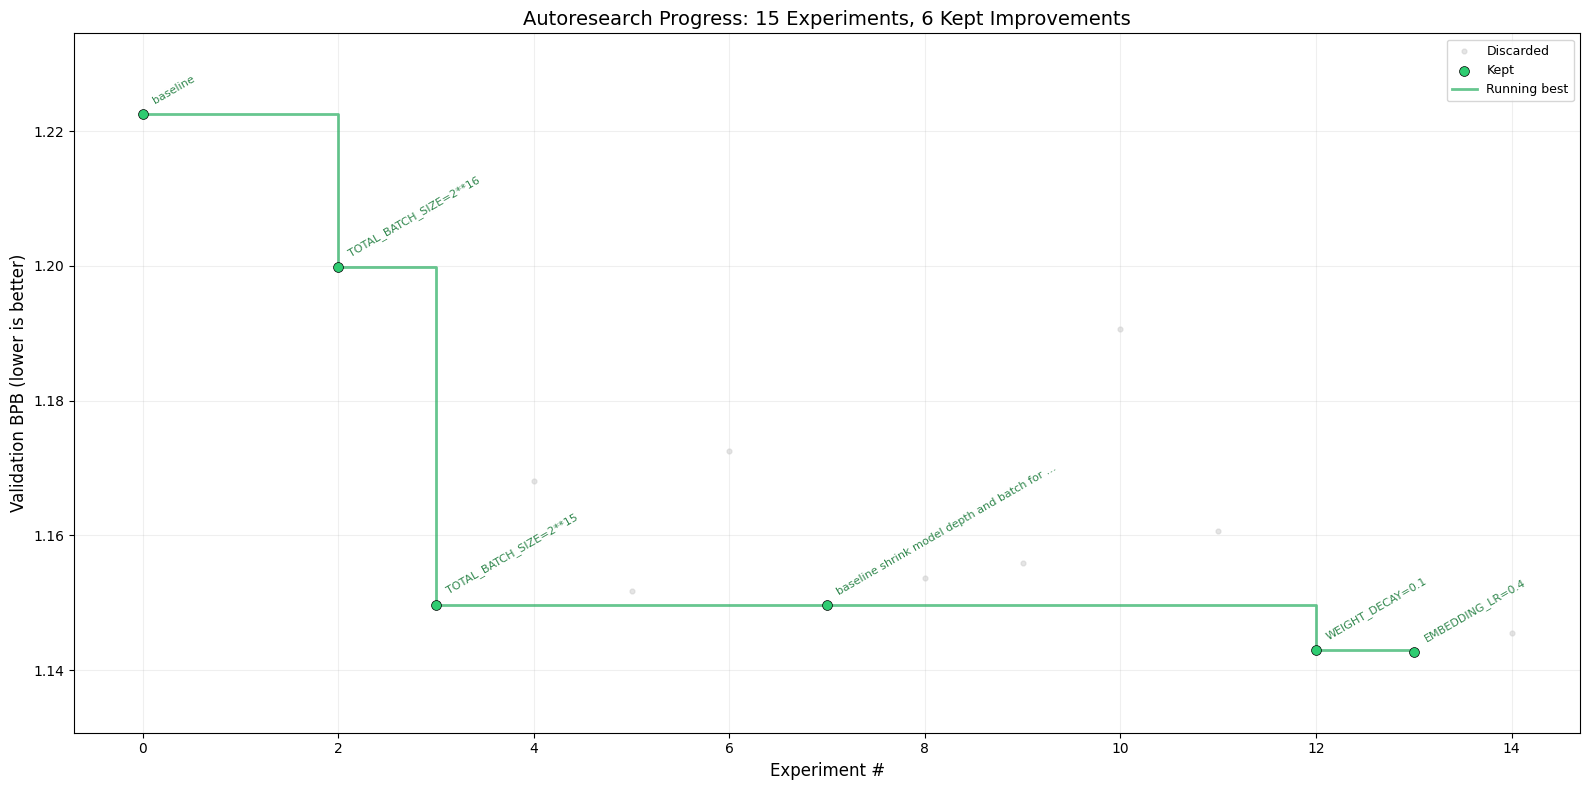

Saved to progress.png


In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best = kept_bpb.min()
margin = (baseline_bpb - best) * 0.15
ax.set_ylim(best - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [ ]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for _, row in kept_sorted.iterrows():
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.222551
Best val_bpb:      1.142676
Total improvement: 0.079875 (6.53%)
Best experiment:   EMBEDDING_LR=0.4

Cumulative effort per improvement:
  Experiment #  0: bpb=1.222551  baseline
  Experiment #  2: bpb=1.199831  TOTAL_BATCH_SIZE=2**16
  Experiment #  3: bpb=1.149729  TOTAL_BATCH_SIZE=2**15
  Experiment #  7: bpb=1.149594  baseline shrink model depth and batch for 8GB GPU
  Experiment # 12: bpb=1.142998  WEIGHT_DECAY=0.1
  Experiment # 13: bpb=1.142676  EMBEDDING_LR=0.4


## Top Hits (Kept Experiments by Improvement)

In [ ]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.050102  1.149729  TOTAL_BATCH_SIZE=2**15
   2  +0.022720  1.199831  TOTAL_BATCH_SIZE=2**16
   3  +0.006596  1.142998  WEIGHT_DECAY=0.1
   4  +0.000322  1.142676  EMBEDDING_LR=0.4
   5  +0.000135  1.149594  baseline shrink model depth and batch for 8GB GPU

      +0.079875              TOTAL improvement over baseline


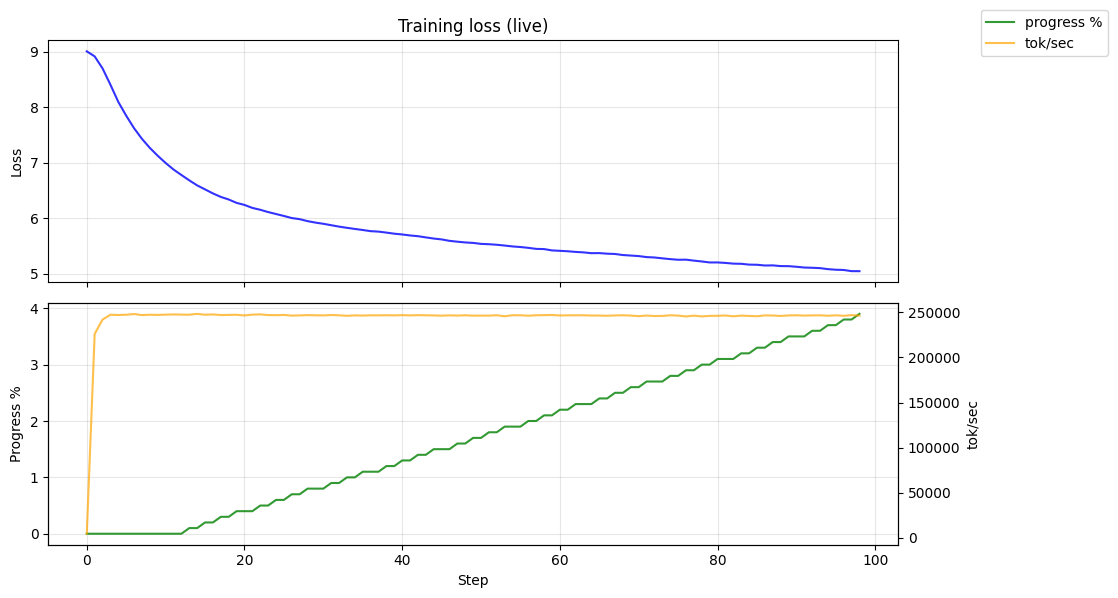

Steps: 98, Loss: 5.0432, Progress: 3.9%, tok/sec: 246,447
Stopped.


In [9]:
# Live plot of run.log while training is running (re-run this cell, then start uv run train.py > run.log 2>&1)
import re
import time
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import clear_output

LOG_PATH = Path("run.log")
INTERVAL = 2  # seconds between updates

def parse_run_log(path):
    """Parse step lines from run.log; return (steps, losses, pct_done, tok_per_sec)."""
    steps, losses, pcts, toksec = [], [], [], []
    if not path.exists():
        return steps, losses, pcts, toksec
    # step 00042 (3.7%) | loss: 5.639463 | lrm: 1.00 | dt: 360ms | tok/sec: 91,077 | mfu: 3.4% | ...
    pattern = re.compile(
        r"step\s+(\d+)\s+\(([\d.]+)%\)\s+\|\s+loss:\s+([\d.]+)\s+\|.*tok/sec:\s+([\d,]+)"
    )
    with open(path, "r") as f:
        for line in f:
            if (m := pattern.search(line)):
                steps.append(int(m[1]))
                pcts.append(float(m[2]))
                losses.append(float(m[3]))
                toksec.append(int(m[4].replace(",", "")))
    return steps, losses, pcts, toksec

print("Watching run.log — start training in another terminal: uv run train.py > run.log 2>&1")
print("Interrupt this cell (Stop) when done.\n")

try:
    while True:
        clear_output(wait=True)
        steps, losses, pcts, toksec = parse_run_log(LOG_PATH)
        if not steps:
            print("No step lines in run.log yet. Waiting...")
            time.sleep(INTERVAL)
            continue
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        axes[0].plot(steps, losses, "b-", alpha=0.8)
        axes[0].set_ylabel("Loss")
        axes[0].set_title("Training loss (live)")
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(steps, pcts, "g-", alpha=0.8, label="progress %")
        ax2 = axes[1].twinx()
        ax2.plot(steps, toksec, "orange", alpha=0.7, label="tok/sec")
        axes[1].set_ylabel("Progress %")
        ax2.set_ylabel("tok/sec")
        axes[1].set_xlabel("Step")
        axes[1].grid(True, alpha=0.3)
        fig.legend(loc="upper right", bbox_to_anchor=(1.12, 1))
        plt.tight_layout()
        plt.show()
        print(f"Steps: {steps[-1]}, Loss: {losses[-1]:.4f}, Progress: {pcts[-1]:.1f}%, tok/sec: {toksec[-1]:,}")
        time.sleep(INTERVAL)
except KeyboardInterrupt:
    print("Stopped.")